# Section 6.3

## Example 6.3.2

We encode the predator–prey equations via a function.

In [9]:
function predprey(u, p, t)
    α, β = p      # rename parameters for convenience
    y, z = u      # rename solution components
    s = (y * z) / (1 + β * y)     # appears in both equations
    return [y * (1 - α * y) - s, -z + s]
end;

As before, the ODE function must accept three inputs, `u`, `p`, and `t`, even though in this case there is no explicit dependence on `t`. The second input is used to pass parameters that don't change throughout a single instance of the problem.

To specify the IVP, we must also provide the initial condition, which is a 2-vector here, and the interval for the independent variable.

In [10]:
using OrdinaryDiffEq
u₀ = [1, 0.01]
tspan = (0.0, 60.0)
α, β = 0.1, 0.25
ivp = ODEProblem(predprey, u₀, tspan, [α, β])

ODEProblem with uType Vector{Float64} and tType Float64. In-place: false
Non-trivial mass matrix: false
timespan: (0.0, 60.0)
u0: 2-element Vector{Float64}:
 1.0
 0.01

You can use any `DifferentialEquations` solver on the IVP system.

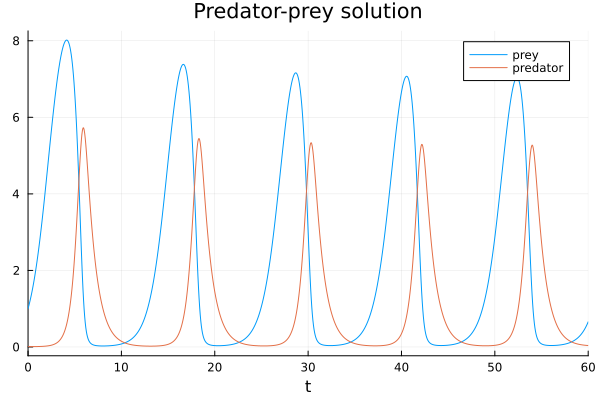

In [ ]:
using Plots, LaTeXStrings
sol = solve(ivp, Tsit5());
plot(sol, label=["prey" "predator"], title="Predator-prey solution")

We can find the discrete values used to compute the interpolated solution. The `sol.u` value is a vector of vectors.

In [12]:
t, u = sol.t, sol.u    # extract times and solution values
@show size(u);
@show t[20];
@show u[20];

size(u) = (100,)
t[20] = 8.386698083051241
u[20] = [0.027739191695661334, 0.699418322938034]


We can also use {numref}`Function {number} <function-euler>` to find the solution.

In [13]:
using FNCFunctions
t, u = FNC.euler(ivp, 1200);

The solution `u` is a vector of [prey,predator] 2-vectors for each of the discrete times in `t`. Manipulating the vector-of-vectors output can be a little tricky. Here, we convert it to an $n\times 2$ matrix. Each column is one component, while each row is a single value of $t$.

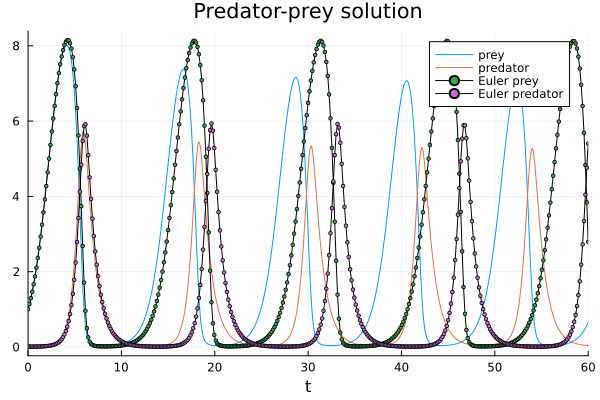

In [ ]:
u = [u[j] for u in u, j in 1:2]
plot!(t[1:3:end], u[1:3:end, :];
    l=(1, :black),  m=2, label=["Euler prey" "Euler predator"])

Notice above that the accuracy of the Euler solution deteriorates rapidly.

When there are just two components, it's common to plot the solution in the _phase plane_, i.e., with $u_1$ and $u_2$ along the axes and time as a parameterization of the curve.

```{tip}
You can use `idxs` in the plot of a solution produced by `solve` to specify the components of the solution that appear on each axis.
```

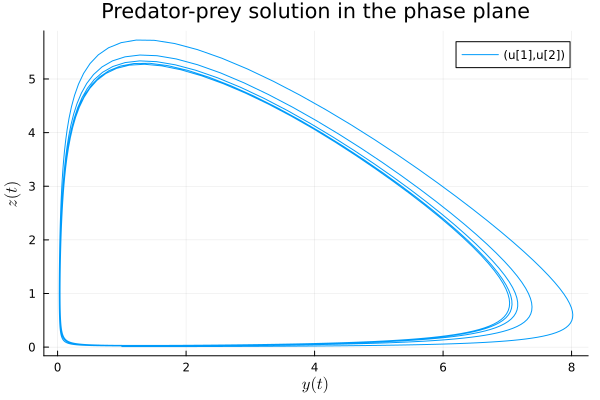

In [15]:
plot(sol, idxs=(1, 2),
    title="Predator-prey solution in the phase plane",
    xlabel=L"y(t)",  ylabel=L"z(t)")

As time progresses, the point in the phase plane spirals inward toward a limiting closed loop called a *limit cycle* representing a periodic solution:

In [17]:
prey, predator = [], []
anim = @animate for t in range(0, 60, 801)
    y, z = sol(t)
    plot(prey, predator;
        title="Predator-prey solution in the phase plane",
        xlabel=L"y(t)",  ylabel=L"z(t)", legend=false)
    push!(prey, y)
    push!(predator, z)
    scatter!([y], [z], m=(5, :red))
    xlims!(0, 9)
    ylims!(0, 6)
end
mp4(anim, "predator-prey.mp4")

┌ Info: Saved animation to /Users/driscoll/Documents/GitHub/fnc/demos/predator-prey.mp4
└ @ Plots /Users/driscoll/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/Users/driscoll/Documents/GitHub/fnc/demos/predator-prey.mp4")

## Example 6.3.5

In [18]:
function couple(u, p, t)
    γ, L, k = p
    g = 9.8
    udot = similar(u)
    udot[1:2] .= u[3:4]
    udot[3] = -γ * u[3] - (g / L) * sin(u[1]) + k * (u[2] - u[1])
    udot[4] = -γ * u[4] - (g / L) * sin(u[2]) + k * (u[1] - u[2])
    return udot
end

u₀ = [1.25, -0.3, 0, 0]
tspan = (0.0, 50.0);

First we check the behavior of the system when the pendulums are uncoupled, i.e., when $k=0$.

```{tip}
Here `idxs` is used to plot two components as functions of time.
```

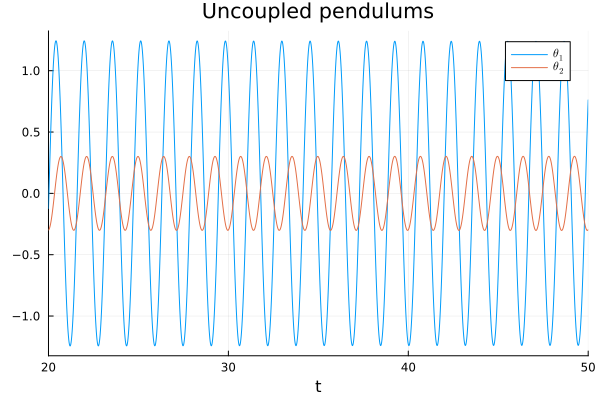

In [ ]:
using OrdinaryDiffEq, Plots, LaTeXStrings
γ, L, k = 0, 0.5, 0
ivp = ODEProblem(couple, u₀, tspan, [γ, L, k])
sol = solve(ivp, Tsit5())
plot(sol, idxs=[1, 2], 
    label=[L"\theta_1" L"\theta_2"], xlims=[20, 50], title="Uncoupled pendulums")

You can see that the pendulums swing independently:

In [22]:
using Printf
anim = @animate for t in range(0, 24, 251)
    θ₁, θ₂, _ = sol(t)
    plot([0, sin(θ₁)], [0, -cos(θ₁)], l=4;
        layout=(1, 2), aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    plot!([0, sin(θ₂)], [0, -cos(θ₂)], l=4;
        subplot=2, aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    scatter!([sin(θ₁)], [-cos(θ₁)], m=(5, :black), subplot=1)
    scatter!([sin(θ₂)], [-cos(θ₂)], m=(5, :black), subplot=2)
    annotate!(-0.95, 0.25, Plots.text(@sprintf("t = %.1f", t), :left, 11); subplot=1)
end
mp4(anim, "pendulums-weak.mp4")

┌ Info: Saved animation to /Users/driscoll/Documents/GitHub/fnc/demos/pendulums-weak.mp4
└ @ Plots /Users/driscoll/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/Users/driscoll/Documents/GitHub/fnc/demos/pendulums-weak.mp4")

In [ ]:
k = 1
ivp = ODEProblem(couple, u₀, tspan, [γ, L, k])
sol = solve(ivp, Tsit5())
plot(sol, idxs=[1, 2], 
    label=[L"\theta_1" L"\theta_2"], xlims=[20, 50], title="Coupled pendulums")

The coupling makes the pendulums swap energy back and forth:

In [ ]:
anim = @animate for t in range(0, 50, 601)
    θ₁, θ₂, _ = sol(t)
    plot([0, sin(θ₁)], [0, -cos(θ₁)], l=4;
        layout=(1, 2), aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    plot!([0, sin(θ₂)], [0, -cos(θ₂)], l=4;
        subplot=2, aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    scatter!([sin(θ₁)], [-cos(θ₁)], m=(5, :black), subplot=1)
    scatter!([sin(θ₂)], [-cos(θ₂)], m=(5, :black), subplot=2)
    annotate!(-0.95, 0.1, Plots.text(@sprintf("t = %.1f", t), :left, 11); subplot=1)
end
mp4(anim, "pendulums-strong.mp4")